**Exercise 6.4**

MNIST with fully connected networks and grid/random search

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tabulate import tabulate
from tensorflow.keras import layers

plt.style.use("seaborn-v0_8")

The MNIST data base of handwritten numbers is directly available through KERAS. The following codeblocks download and preprocess the data.

In [10]:
with np.load('../datasets/mnist.npz') as f:
    x_train, y_train = f['x_train'], f['y_train']
    x_test, y_test = f['x_test'], f['y_test']

x_valid = x_test[8000:]
y_valid = y_test[8000:]
x_test = x_test[:8000]
y_test = y_test[:8000]

# Hint: convert integer RGB values (0-255) to float values (0-1)
x_train = np.float32(x_train) / 255
x_valid = np.float32(x_valid) / 255
x_test = np.float32(x_test) / 255

In [11]:
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_valid.shape[0], "validation samples")
print(x_test.shape[0], "test samples")

x_train shape: (60000, 28, 28)
60000 train samples
2000 validation samples
8000 test samples


In this exercise, a fully connected neural network is used to predict the handwritten numbers. To do this, we reformat the pictures with 28x28 pixels into a vector with a length of 28x28=784.

In [12]:
# reshape the image matrices to vectors
x_train = x_train.reshape(-1, 28**2)
x_valid = x_valid.reshape(-1, 28**2)
x_test = x_test.reshape(-1, 28**2)
print("x_train shape:", x_train.shape)

x_train shape: (60000, 784)


We use "onehot" encoding of the classes. This means a "zero" is encoded as `[1,0,0,0,0,0,0,0,0,0]` and a "one" as `[0,1,0,0,0,0,0,0,0,0]` etc.
This is done because our network will have ten output nodes with the output node with the largest value being the predicted number.

In [13]:
# convert class vectors to binary class matrices (10 numbers/classes)
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_valid_onehot = tf.keras.utils.to_categorical(y_valid, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)

In [14]:
# define model here
model = tf.keras.models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10),
    # softmax activation to transform output into probabilities
    layers.Activation('softmax')])

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [15]:
model.compile(
    # the recommended loss for a classification task is 'categorical_crossentropy'
    # (see lecture for details)
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']) # we use accuracy to quanitfy to network performance.

# define callbacks for training
save_best = tf.keras.callbacks.ModelCheckpoint(
    "checkpoints/best_model_{}.weights.h5".format(model.name),
    save_best_only=True,
    monitor="val_accuracy",
    save_weights_only=True,
)

# Keras calculates training accuracy and loss during the training and
# with regularization applied, while the validation metrics are calculated
# at the end of each epoch. This callback calculates the training metrics
# the same way as for the validation
class CalculateMetrics(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        train_loss, train_acc = model.evaluate(x_train, y_train_onehot, verbose=0)
        logs["train_loss"] = train_loss
        logs["train_acc"] = train_acc

results = model.fit(
    x_train, y_train_onehot,
    validation_data=(x_valid, y_valid_onehot),

    batch_size=32,
    epochs=10,
    callbacks=[
        save_best,
        CalculateMetrics(),
        tf.keras.callbacks.CSVLogger("checkpoints/history_{}.csv".format(model.name))
    ]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9143 - loss: 0.2938 - val_accuracy: 0.9660 - val_loss: 0.1082 - train_loss: 0.1335 - train_acc: 0.9605
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9577 - loss: 0.1443 - val_accuracy: 0.9745 - val_loss: 0.0782 - train_loss: 0.0868 - train_acc: 0.9748
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9665 - loss: 0.1090 - val_accuracy: 0.9760 - val_loss: 0.0778 - train_loss: 0.0681 - train_acc: 0.9794
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9725 - loss: 0.0894 - val_accuracy: 0.9820 - val_loss: 0.0570 - train_loss: 0.0471 - train_acc: 0.9858
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9760 - loss: 0.0759 - val_accuracy: 0.9840 - val_loss: 0.0498 - train_loss: 0.0399 - train_acc: 0.9878
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9784 - loss: 0.0675 - val_accuracy: 0.9850 - val_loss: 0.0518 - train_loss: 0

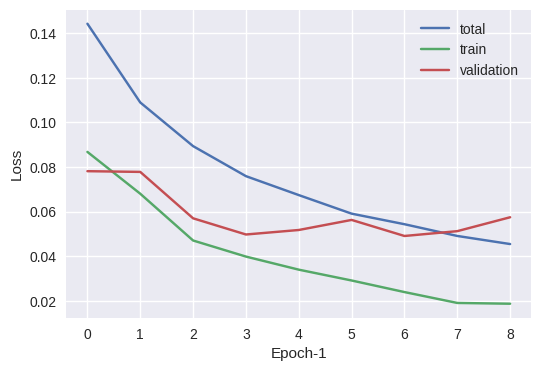

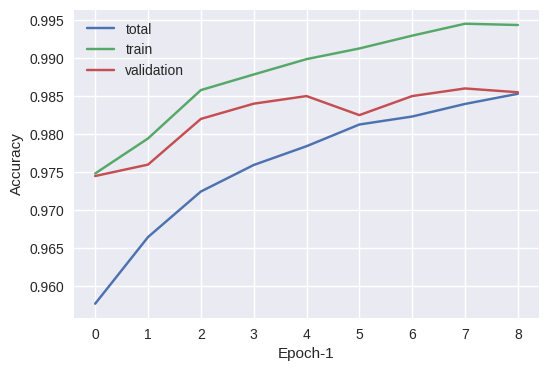

In [16]:
# load best model
model.load_weights(f"checkpoints/best_model_{model.name}.weights.h5")

# ------------------------
# ---     Plotting     ---
# ------------------------

# plot training history
history = np.genfromtxt(f"checkpoints/history_{model.name}.csv", delimiter=",", names=True)
# add plots below
loss = history["loss"][1:]
train_loss = history["train_loss"][1:]
test_loss = history["val_loss"][1:]

acc = history["accuracy"][1:]
train_acc = history["train_acc"][1:]
test_acc = history["val_accuracy"][1:]

# Plot loss over time
plt.figure(figsize=(6, 4))
plt.plot(loss, label="total")
plt.plot(train_loss,label="train")
plt.plot(test_loss,label="validation")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(acc, label="total")
plt.plot(train_acc,label="train")
plt.plot(test_acc,label="validation")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Accuracy")
plt.show()


In [17]:
# evaluate performance

print("Model performance :")
headers = ["", "Loss", "Accuracy", "Test error rate [%]"]

table = [
    [
        "Train",
        *model.evaluate(x_train, y_train_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_train, y_train_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Validation",
        *model.evaluate(x_valid, y_valid_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_valid, y_valid_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Test",
        *model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)[1]) * 100,
    ],
]

print(tabulate(table, headers=headers, tablefmt="orgtbl"))

Model performance :
|            |      Loss |   Accuracy |   Test error rate [%] |
|------------+-----------+------------+-----------------------|
| Train      | 0.0191047 |     0.9945 |              0.550002 |
| Validation | 0.0512869 |     0.986  |              1.4      |
| Test       | 0.0675562 |     0.979  |              2.1      |


You can compare your own results with a variety of different models: http://yann.lecun.com/exdb/mnist/ and https://en.wikipedia.org/wiki/MNIST_database

The following codeblocks define some helper functions for plotting. You don't need to touch them

In [18]:
# @title
def plot_image(X, ax=None):
    """Plot an image X.

    Args:
        X (2D array): image, grayscale or RGB
        ax (None, optional): Description
    """
    if ax is None:
        ax = plt.gca()

    if (X.ndim == 2) or (X.shape[-1] == 1):
        ax.imshow(X.astype("uint8"), origin="upper", cmap=plt.cm.Greys)
    else:
        ax.imshow(X.astype("uint8"), origin="upper")

    ax.set(xticks=[], yticks=[])


def plot_prediction(Yp, X, y, classes=None, top_n=False):
    """Plot an image along with all or the top_n predictions.

    Args:
        Yp (1D array): predicted probabilities for each class
        X (2D array): image
        y (integer): true class label
        classes (1D array, optional): class names
        top_n (int, optional): number of top predictions to show
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.2))
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.15, top=0.98, wspace=0.02)
    plot_image(X, ax1)

    if top_n:
        n = top_n
        s = np.argsort(Yp)[-top_n:]
    else:
        n = len(Yp)
        s = np.arange(n)[::-1]

    patches = ax2.barh(np.arange(n), Yp[s], align="center")
    ax2.set(xlim=(0, 1), xlabel="Probability", yticks=[])

    for iy, patch in zip(s, patches):
        if iy == y:
            patch.set_facecolor("C1")  # color correct patch

    if classes is None:
        classes = np.arange(0, np.size(Yp))

    for i in range(n):
        ax2.text(0.05, i, classes[s][i], ha="left", va="center")

    plt.show()


def plot_confusion(yp, y, classes=None, fname=None):
    """Plot confusion matrix for given true and predicted class labels

    Args:
        yp (1D array): predicted class labels
        y (1D array): true class labels
        classes (1D array): class names
        fname (str, optional): filename for saving the plot
    """
    if classes is None:
        n = max(max(yp), max(y)) + 1
        classes = np.arange(n)
    else:
        n = len(classes)

    bins = np.linspace(-0.5, n - 0.5, n + 1)
    C = np.histogram2d(y, yp, bins=bins)[0]
    C = C / np.sum(C, axis=0) * 100

    _ = plt.figure(figsize=(8, 8))
    plt.imshow(C, interpolation="nearest", vmin=0, vmax=100, cmap=plt.cm.YlGnBu)
    plt.gca().set_aspect("equal")
    cbar = plt.colorbar(shrink=0.8)
    cbar.set_label("Frequency %")
    plt.xlabel("Prediction")
    plt.ylabel("Truth")
    plt.xticks(range(n), classes, rotation="vertical")
    plt.yticks(range(n), classes)
    for x in range(n):
        for y in range(n):
            if np.isnan(C[x, y]):
                continue
            color = "white" if x == y else "black"
            plt.annotate(
                "%.1f" % (C[x, y]), xy=(y, x), color=color, ha="center", va="center"
            )

    plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


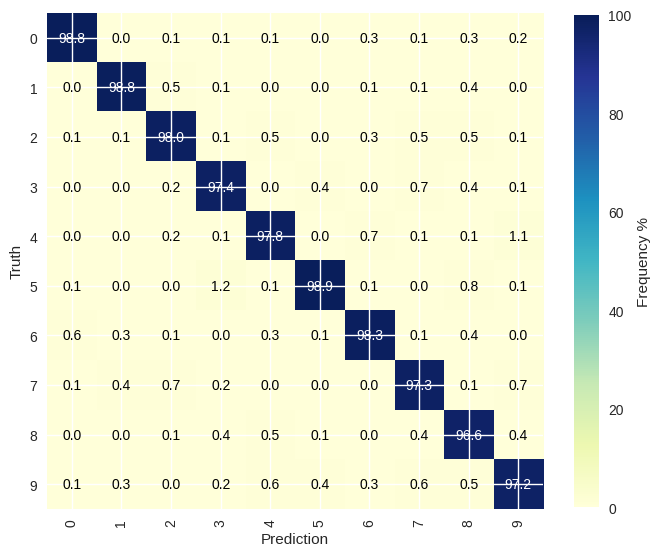

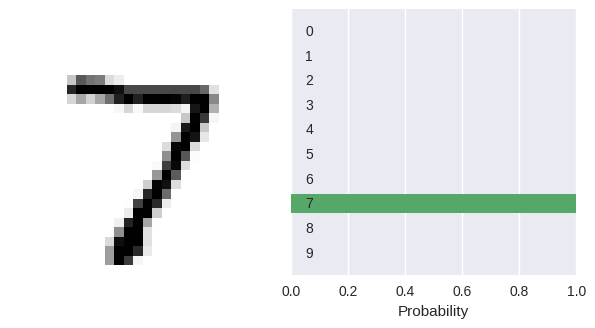

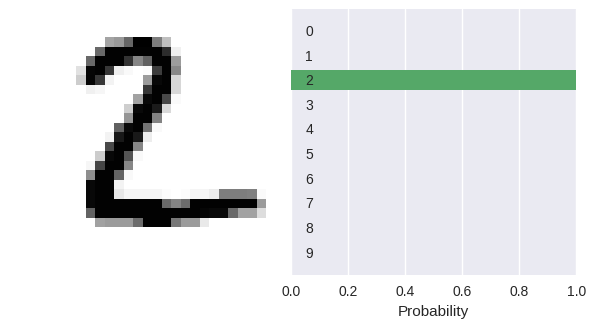

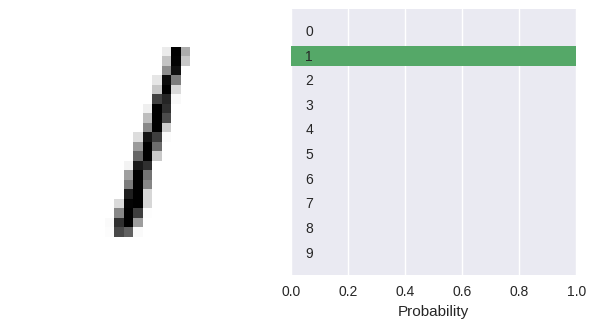

In [19]:
# plot a few examples, loop over test dataset:
# get missidentified samples
output = model.predict(x_test, batch_size=128)
labels = np.argmax(y_test_onehot, axis=1)
predictions = np.argmax(output, axis=1)
plot_confusion(predictions, labels)

for i in range(3): # loop over first 10 test samples
    plot_prediction(output[i],
                    255 * np.reshape(x_test[i], (28, 28)), # we need to reshape the data into an image and convert back to RGB color scale by multiplying with 255
                    labels[i])


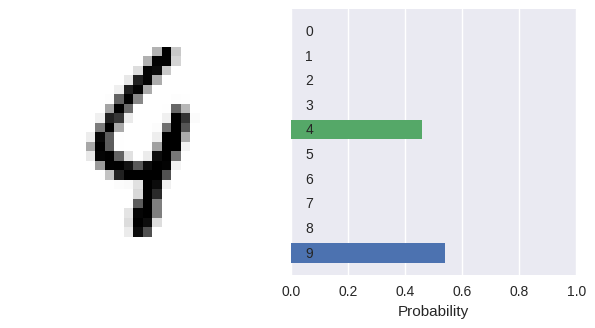

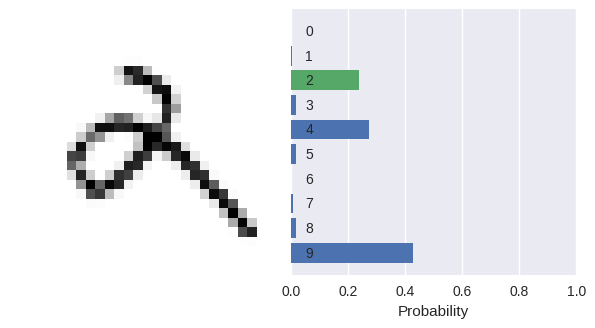

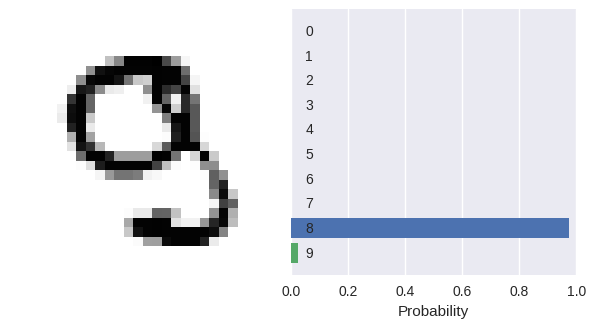

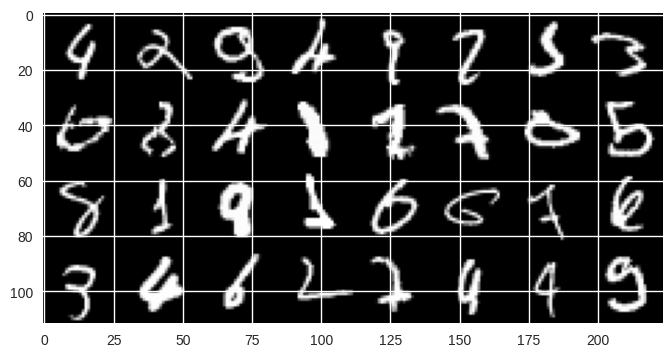

In [20]:
# now plot a few examples that were misclassified

indices_miss = np.nonzero(predictions != labels)[0]
x_missid = x_test[indices_miss]

for i in indices_miss[:3]:
    plot_prediction(output[i],
                    255 * np.reshape(x_test[i], (28, 28)), # we need to reshape the data into an image and convert back to RGB color scale by multiplying with 255
                    labels[i])

# or plot 32 of them in a joint plot
fig = plt.figure()
ax = fig.add_subplot(111)
plotdata = x_missid[:32]
plotdata = np.hstack(np.concatenate(np.reshape(plotdata, (4, 8, 28, 28)), axis=1))
ax.imshow(plotdata, cmap="gray")


**Grid search**

Let's search the two hyperparameters dropout and number of nodes. You can start from the template below.



In [ ]:
dropout_values = [0.2, 0.3, 0.5]
n_neurons_values = [64, 128, 256]
results_gridsearch = np.zeros((len(dropout_values), len(n_neurons_values), 2))
for iDrop, drop in enumerate(dropout_values):
  for iN, n_neurons in enumerate(n_neurons_values):
    model = tf.keras.models.Sequential([
                layers.Input(shape=(784,)),
                layers.Dense(n_neurons, activation='relu'),
                layers.Dropout(drop),
                layers.Dense(10),
                # softmax activation to transform output into probabilities
                layers.Activation('softmax')])

    model.compile(
        # the recommended loss for a classification task is 'categorical_crossentropy'
        # (see lecture for details)
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']) # we use accuracy to quanitfy to network performance.

    results = model.fit(
        x_train, y_train_onehot,
        validation_data=(x_valid, y_valid_onehot),
        batch_size=32,
        epochs=10,
        verbose=0
        )
    t = model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)
    results_gridsearch[iDrop, iN] = t
    print(f"dropout = {drop:.2f}, {n_neurons} neurons -> accuracy {results_gridsearch[iDrop, iN][1]:.3f}, error rate = {100*(1-results_gridsearch[iDrop, iN][1]):.1f}%")


dropout = 0.20, 64 neurons -> accuracy 0.974, error rate = 2.6%
dropout = 0.20, 128 neurons -> accuracy 0.978, error rate = 2.2%
dropout = 0.20, 256 neurons -> accuracy 0.980, error rate = 2.0%
dropout = 0.30, 64 neurons -> accuracy 0.969, error rate = 3.1%
dropout = 0.30, 128 neurons -> accuracy 0.978, error rate = 2.2%
dropout = 0.30, 256 neurons -> accuracy 0.979, error rate = 2.1%
dropout = 0.50, 64 neurons -> accuracy 0.967, error rate = 3.3%
dropout = 0.50, 128 neurons -> accuracy 0.973, error rate = 2.7%
dropout = 0.50, 256 neurons -> accuracy 0.979, error rate = 2.1%


**Random seach**

Now lets implement a random search. A random search allows us to scan more hyperparameters at once without more computing time. You can start from the template below.




In [ ]:
N = 20 # number of trials
search = {
    'batch_size': np.random.choice([16, 32, 64, 128, 256], N),
    'num_neurons': np.random.choice([8, 32, 128, 256, 512], N),
    'learn_rate': np.random.choice([1e-5, 1e-4, 1e-3, 1e-2, 1e-1], N),
    'activation': np.random.choice(['relu', 'elu', 'sigmoid', 'tanh'], N),
    'dropout': np.random.choice([0.0, 0.1, 0.2, 0.3, 0.5, 0.6], N),
    'val_acc': np.zeros(N)
}

for i in range(N):
  # you can access the current value of the hyperparameter with `search['batch_size'][i]`
  model = model = tf.keras.models.Sequential([
                layers.Input(shape=(784,)),
                layers.Dense(int(search['num_neurons'][i]), activation=search['activation'][i]),
                layers.Dropout(search['dropout'][i]),
                layers.Dense(10),
                # softmax activation to transform output into probabilities
                layers.Activation('softmax')])
  model.compile(loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=search['learn_rate'][i]),
    metrics=['accuracy'])
  
  results = model.fit(
        x_train, y_train_onehot,
        validation_data=(x_valid, y_valid_onehot),
        batch_size=search['batch_size'][i],
        epochs=10,
        verbose=0
      )
  search['val_acc'][i] = model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)[1]
  print(f"iteration {i}:")
  for key in search:
    print(f"\t{key}: {search[key][i]}")
  print(f"\t-> accuracy {search['val_acc'][i]:.3f}, error rate = {100*(1-search['val_acc'][i]):.1f}%")


iteration 0:
	batch_size: 64
	num_neurons: 8
	learn_rate: 0.0001
	activation: elu
	dropout: 0.2
	val_acc: 0.878250002861023
	-> accuracy 0.878, error rate = 12.2%
iteration 1:
	batch_size: 256
	num_neurons: 32
	learn_rate: 0.1
	activation: sigmoid
	dropout: 0.2
	val_acc: 0.9238749742507935
	-> accuracy 0.924, error rate = 7.6%
iteration 2:
	batch_size: 64
	num_neurons: 32
	learn_rate: 1e-05
	activation: elu
	dropout: 0.5
	val_acc: 0.8393750190734863
	-> accuracy 0.839, error rate = 16.1%
iteration 3:
	batch_size: 32
	num_neurons: 128
	learn_rate: 0.001
	activation: tanh
	dropout: 0.6
	val_acc: 0.9574999809265137
	-> accuracy 0.957, error rate = 4.3%
iteration 4:
	batch_size: 32
	num_neurons: 256
	learn_rate: 0.01
	activation: elu
	dropout: 0.0
	val_acc: 0.9672499895095825
	-> accuracy 0.967, error rate = 3.3%
iteration 5:
	batch_size: 32
	num_neurons: 8
	learn_rate: 0.1
	activation: sigmoid
	dropout: 0.1
	val_acc: 0.8516250252723694
	-> accuracy 0.852, error rate = 14.8%
iteration 6:
	